In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("/content/Fraudulent Transactions Data.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
206149,13,PAYMENT,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.0,0.00,0.0,0.0
206150,13,TRANSFER,26029.23,C955702923,11701.00,0.00,C1593503248,0.0,26029.23,0.0,0.0
206151,13,PAYMENT,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.0,0.00,0.0,0.0
206152,13,PAYMENT,18011.97,C674603509,450892.07,432880.11,M649670910,0.0,0.00,0.0,0.0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,206154.000000,2.061540e+05,2.061540e+05,2.061540e+05,2.061530e+05,2.061530e+05,206153.000000,206153.0
mean,10.153477,1.807203e+05,8.928084e+05,9.109059e+05,9.451124e+05,1.191658e+06,0.000737,0.0
std,2.148655,3.275833e+05,2.811313e+06,2.848760e+06,2.372896e+06,2.648573e+06,0.027144,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.211470e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.000000,6.952972e+04,1.970700e+04,0.000000e+00,5.197200e+04,1.376521e+05,0.000000,0.0
75%,12.000000,2.294577e+05,1.937658e+05,2.301190e+05,7.742127e+05,1.191881e+06,0.000000,0.0
max,13.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206154 entries, 0 to 206153
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            206154 non-null  int64  
 1   type            206154 non-null  object 
 2   amount          206154 non-null  float64
 3   nameOrig        206154 non-null  object 
 4   oldbalanceOrg   206154 non-null  float64
 5   newbalanceOrig  206154 non-null  float64
 6   nameDest        206154 non-null  object 
 7   oldbalanceDest  206153 non-null  float64
 8   newbalanceDest  206153 non-null  float64
 9   isFraud         206153 non-null  float64
 10  isFlaggedFraud  206153 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 17.3+ MB


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [ ]:
df['oldbalanceDest'].fillna(df['oldbalanceDest'].median(), inplace=True)
df['newbalanceDest'].fillna(df['newbalanceDest'].median(), inplace=True)
df['isFraud'].fillna(0, inplace=True)  # Fraud should not be missing
df['isFlaggedFraud'].fillna(0, inplace=True)

<ipython-input-6-f67fe5fc661d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldbalanceDest'].fillna(df['oldbalanceDest'].median(), inplace=True)
<ipython-input-6-f67fe5fc661d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
print("Missing values after handling:\n", df.isnull().sum())


Missing values after handling:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
df = df.drop_duplicates()
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
206149,13,PAYMENT,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.0,0.00,0.0,0.0
206150,13,TRANSFER,26029.23,C955702923,11701.00,0.00,C1593503248,0.0,26029.23,0.0,0.0
206151,13,PAYMENT,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.0,0.00,0.0,0.0
206152,13,PAYMENT,18011.97,C674603509,450892.07,432880.11,M649670910,0.0,0.00,0.0,0.0


<ipython-input-9-b796a0f42990>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['isFraud'], palette='coolwarm')


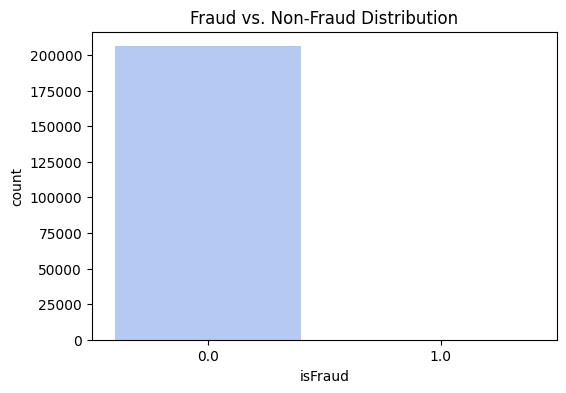

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['isFraud'], palette='coolwarm')
plt.title("Fraud vs. Non-Fraud Distribution")
plt.show()

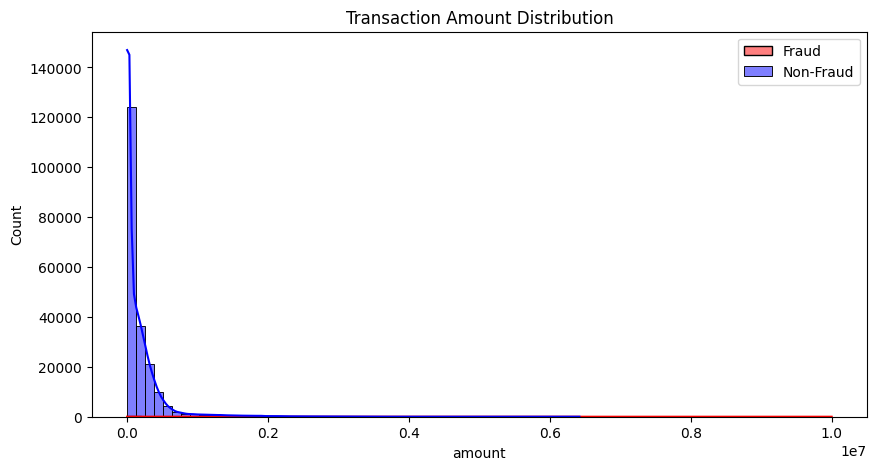

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['isFraud'] == 1]['amount'], bins=50, color='red', label='Fraud', kde=True)
sns.histplot(df[df['isFraud'] == 0]['amount'], bins=50, color='blue', label='Non-Fraud', kde=True)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

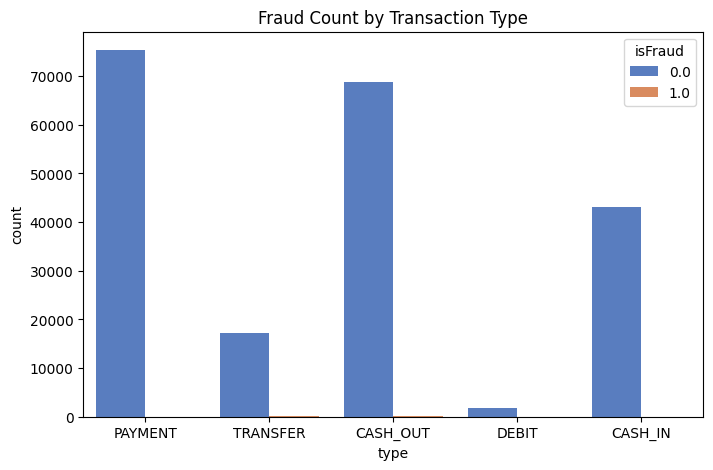

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='muted')
plt.title("Fraud Count by Transaction Type")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df['isFraud'] = df['isFraud'].fillna(0).astype(int)

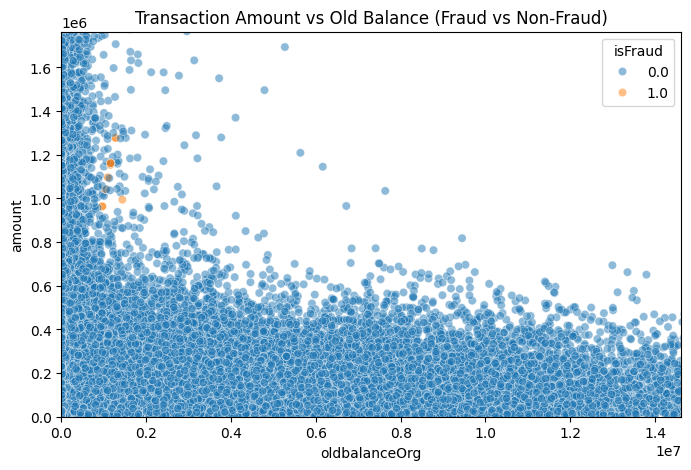

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['oldbalanceOrg'], y=df['amount'], hue=df['isFraud'], alpha=0.5)
plt.xlim(0, df['oldbalanceOrg'].quantile(0.99))
plt.ylim(0, df['amount'].quantile(0.99))
plt.title("Transaction Amount vs Old Balance (Fraud vs Non-Fraud)")
plt.show()

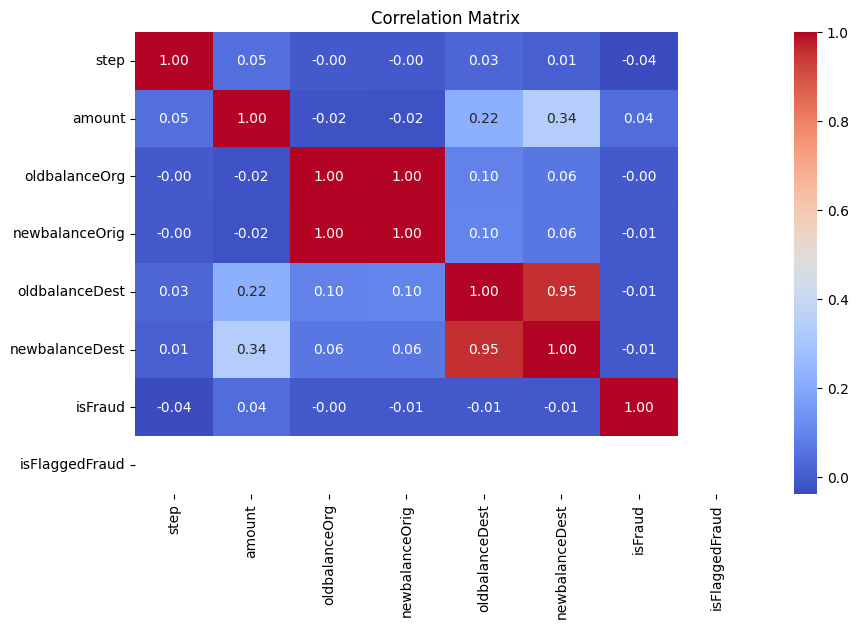

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

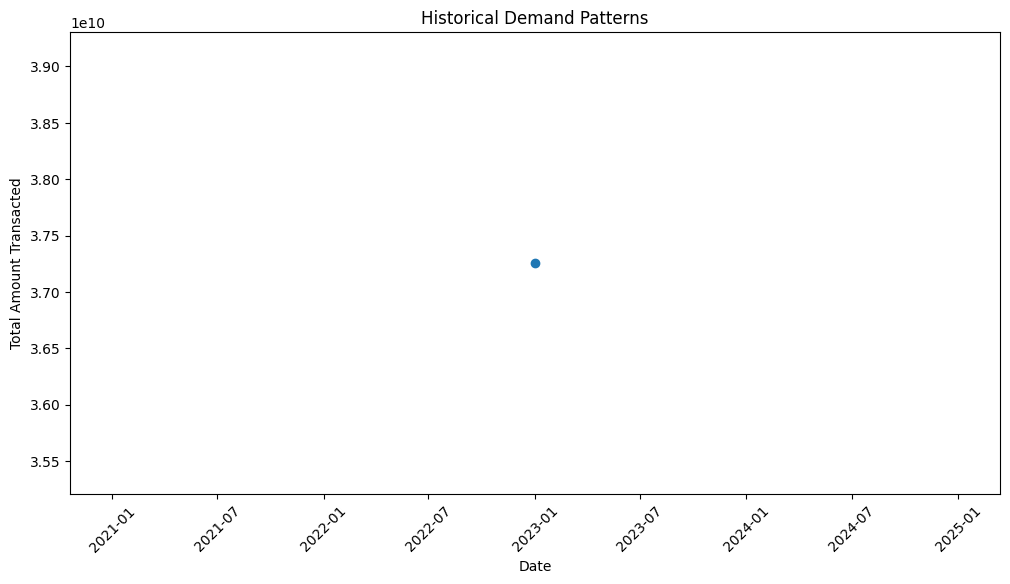

In [ ]:
df['step'] = pd.to_datetime(df['step'], unit='h', origin=pd.Timestamp('2023-01-01'))
demand_trends = df.groupby(df['step'].dt.date)['amount'].sum()
plt.figure(figsize=(12, 6))
plt.plot(demand_trends, marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.title("Historical Demand Patterns")
plt.xlabel("Date")
plt.ylabel("Total Amount Transacted")
plt.show()

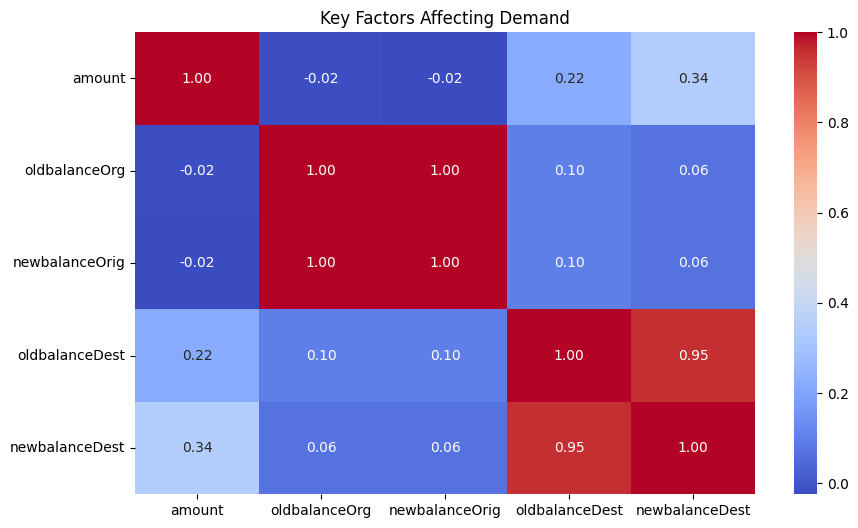

In [ ]:
correlation_demand = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_demand, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Key Factors Affecting Demand")
plt.show()

In [ ]:
df['balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['transaction_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['transaction_gap'] = df.groupby('nameOrig')['step'].diff().fillna(0)
df['balance_change_ratio'] = (df['oldbalanceOrg'] - df['newbalanceOrig']) / (df['oldbalanceOrg'] + 1)
df['recipient_balance_change'] = (df['oldbalanceDest'] - df['newbalanceDest']) / (df['oldbalanceDest'] + 1)
df['large_transaction_flag'] = np.where(df['amount'] > 200000, 1, 0)
df['zero_balance_after_txn'] = np.where(df['newbalanceOrig'] == 0, 1, 0)
df


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change,transaction_ratio,transaction_gap,balance_change_ratio,recipient_balance_change,large_transaction_flag,zero_balance_after_txn
0,2023-01-01 01:00:00,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0.0,...,False,True,False,9839.64,0.057834,0,0.057834,0.000000,0,0
1,2023-01-01 01:00:00,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0.0,...,False,True,False,1864.28,0.087731,0,0.087731,0.000000,0,0
2,2023-01-01 01:00:00,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0.0,...,False,False,True,181.00,0.994505,0,0.994505,0.000000,0,1
3,2023-01-01 01:00:00,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0.0,...,False,False,False,181.00,0.994505,0,0.994505,0.999953,0,1
4,2023-01-01 01:00:00,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0.0,...,False,True,False,11668.14,0.280788,0,0.280788,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206149,2023-01-01 13:00:00,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.0,0.00,0,0.0,...,False,True,False,1562.19,0.001190,0,0.001190,0.000000,0,0
206150,2023-01-01 13:00:00,26029.23,C955702923,11701.00,0.00,C1593503248,0.0,26029.23,0,0.0,...,False,False,True,11701.00,2.224340,0,0.999915,-26029.230000,0,1
206151,2023-01-01 13:00:00,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.0,0.00,0,0.0,...,False,True,False,5931.93,0.012985,0,0.012985,0.000000,0,0
206152,2023-01-01 13:00:00,18011.97,C674603509,450892.07,432880.11,M649670910,0.0,0.00,0,0.0,...,False,True,False,18011.96,0.039947,0,0.039947,0.000000,0,0


In [ ]:
def detect_fraud(row):
    if row['type_TRANSFER'] == 1 and row['large_transaction_flag'] == 1:
        return 1
    if row['type_CASH_OUT'] == 1 and row['zero_balance_after_txn'] == 1:
        return 1
    return 0

df['fraud_flag'] = df.apply(detect_fraud, axis=1)

In [ ]:
df['avg_transaction_amount'] = df.groupby('nameOrig')['amount'].transform('mean')
df['transaction_frequency'] = df.groupby('nameOrig')['step'].transform('count')
df['high_frequency_flag'] = np.where(df['transaction_frequency'] > df['transaction_frequency'].quantile(0.95), 1, 0)

In [ ]:
df['suspicious_transfer'] = np.where((df['type_TRANSFER'] == 1) &
                                     (df['amount'] > df['oldbalanceOrg'] * 0.8), 1, 0)

In [ ]:
df['final_fraud_flag'] = np.where((df['isFraud'] == 1) |
                                  (df['suspicious_transfer'] == 1), True, False)

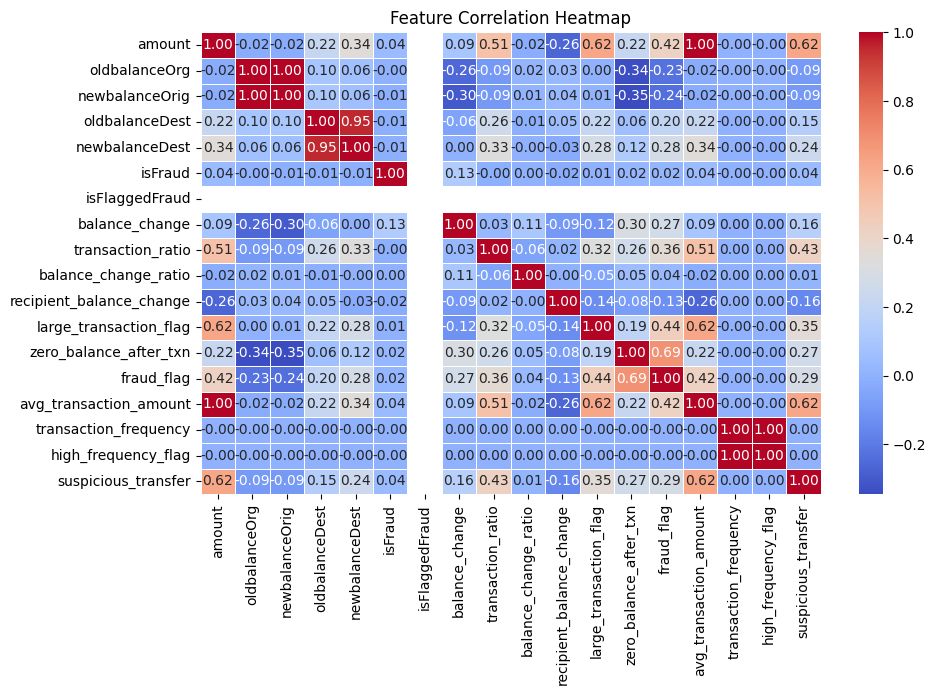

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_change', 'transaction_ratio'] + list(df.columns[df.columns.str.startswith('type_')])
X = df[features]
y = df['isFraud']

In [ ]:
print("Fraud class distribution before resampling:\n", y.value_counts())

Fraud class distribution before resampling:
 isFraud
0    206002
1       152
Name: count, dtype: int64


In [ ]:
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
print("Fraud class distribution after resampling:\n", pd.Series(y_resampled).value_counts())

Fraud class distribution after resampling:
 isFraud
0    206002
1     61800
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=10, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
}

In [ ]:

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred


    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report.get('1', {}).get('precision', np.nan),
        "Recall": report.get('1', {}).get('recall', np.nan),
        "F1-Score": report.get('1', {}).get('f1-score', np.nan),
        "AUC-ROC": auc
    })

results_df = pd.DataFrame(results)
print(results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 49440, number of negative: 164801
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1797
[LightGBM] [Info] Number of data points in the train set: 214241, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230768 -> initscore=-1.203979
[LightGBM] [Info] Start training from score -1.203979


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.968260   0.926810  0.936408  0.931584  0.988966
1        Random Forest  0.999664   0.999030  0.999515  0.999272  0.999984
2              XGBoost  0.998618   0.994287  0.999757  0.997015  0.999960
3             LightGBM  0.999683   0.998868  0.999757  0.999313  0.999999
4       Neural Network  0.996434   0.989541  0.995065  0.992295  0.999713


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


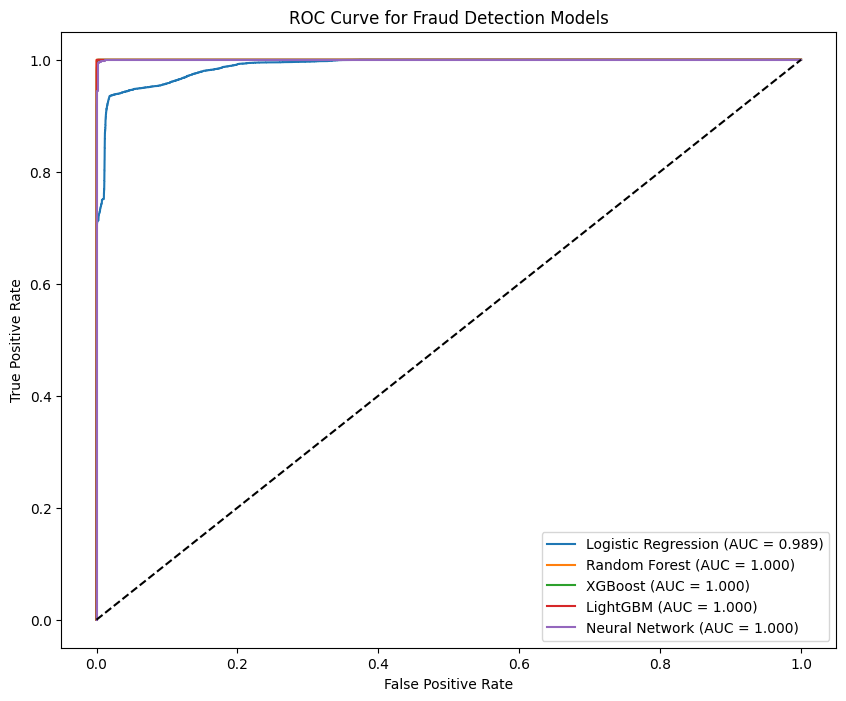

In [ ]:
plt.figure(figsize=(10, 8))

from sklearn.metrics import roc_curve

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fraud Detection Models")
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


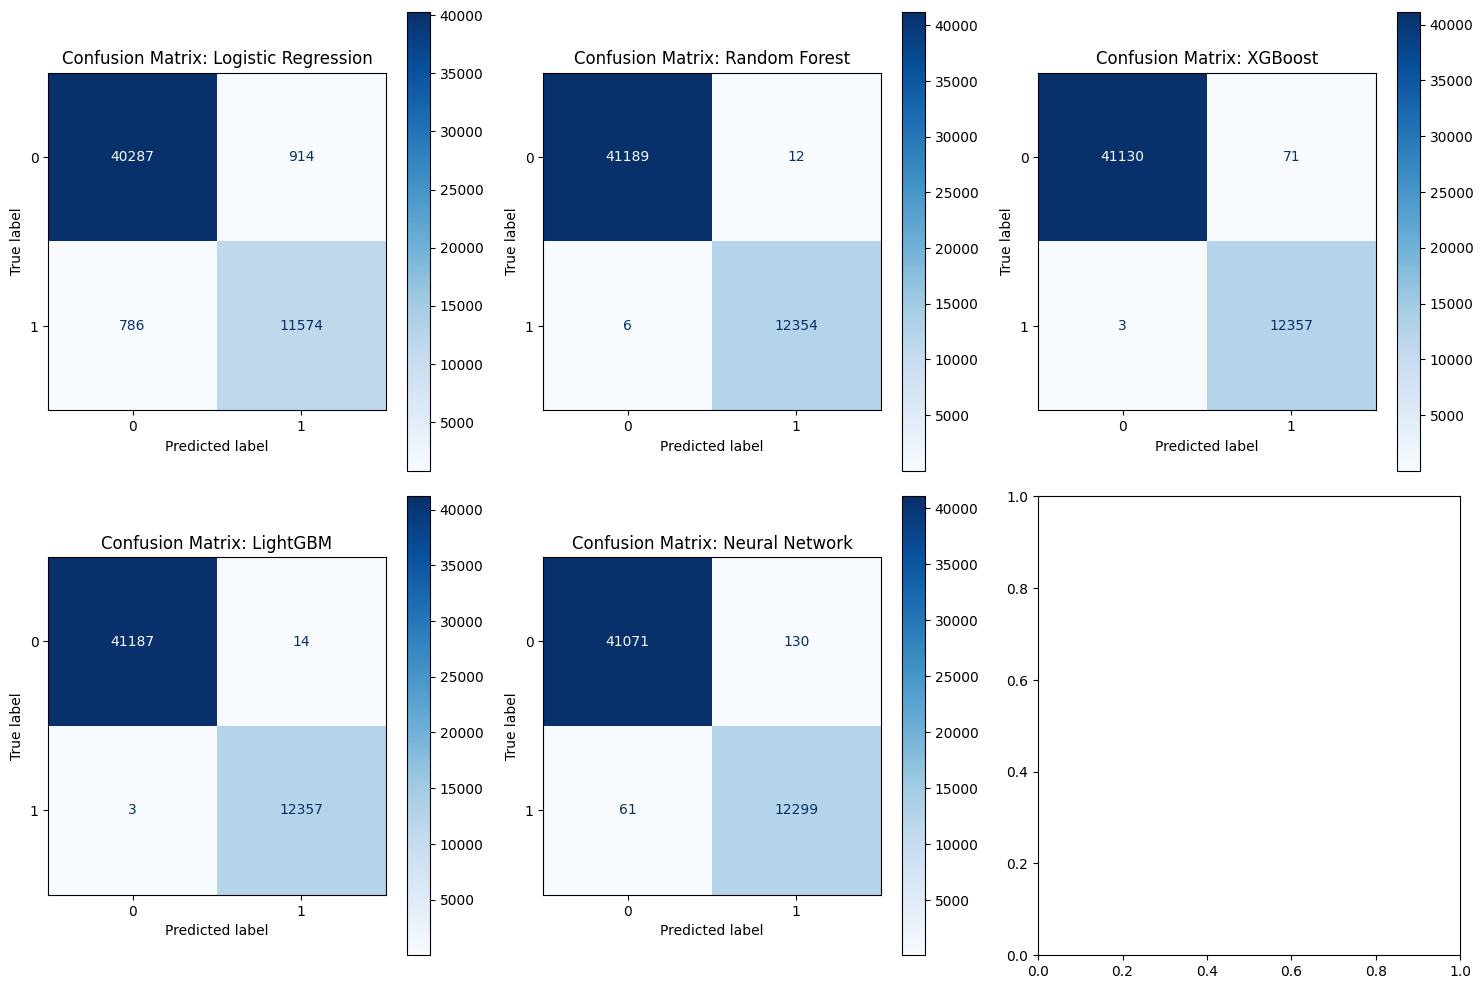

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[idx], cmap="Blues", values_format="d")
    axes[idx].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()


In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:24:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:24:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:24:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:24:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:24:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
best_model = grid.best_estimator_
print("Best Hyperparameters:", grid.best_params_)

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-Validation AUC Scores:", cv_scores)
print("Mean CV AUC:", np.mean(cv_scores))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Cross-Validation AUC Scores: [0.99997294 0.9999488  0.99994501 0.99995679 0.99994797]
Mean CV AUC: 0.9999542999111737


In [ ]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:26:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))

Epoch 1/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9379 - loss: 0.1675 - val_accuracy: 0.9665 - val_loss: 0.0847
Epoch 2/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - accuracy: 0.9705 - loss: 0.0780 - val_accuracy: 0.9776 - val_loss: 0.0762
Epoch 3/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9756 - loss: 0.0670 - val_accuracy: 0.9792 - val_loss: 0.0530
Epoch 4/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9786 - loss: 0.0599 - val_accuracy: 0.9808 - val_loss: 0.0494
Epoch 5/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9813 - loss: 0.0524 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 6/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9832 - loss: 0.0487 - val_accuracy: 0.9823 - val_loss: 0.0470
Epoch 7/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9833 - loss: 0.0477 - val_accuracy: 0.9900 - val_loss: 0.0362
Epoch 8/10
6696/6696 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9847 - loss: 0

In [ ]:
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

1674/1674 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [ ]:
acc_lstm = accuracy_score(y_test, y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_prob_lstm)
report_lstm = classification_report(y_test, y_pred_lstm, output_dict=True)

In [ ]:
results_df = pd.concat([results_df, pd.DataFrame([{
    "Model": "LSTM",
    "Accuracy": acc_lstm,
    "Precision": report_lstm.get('1', {}).get('precision', np.nan),
    "Recall": report_lstm.get('1', {}).get('recall', np.nan),
    "F1-Score": report_lstm.get('1', {}).get('f1-score', np.nan),
    "AUC-ROC": auc_lstm
}])], ignore_index=True)

In [ ]:
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.968260   0.926810  0.936408  0.931584  0.988966
1        Random Forest  0.999664   0.999030  0.999515  0.999272  0.999984
2              XGBoost  0.998618   0.994287  0.999757  0.997015  0.999960
3             LightGBM  0.999683   0.998868  0.999757  0.999313  0.999999
4       Neural Network  0.996434   0.989541  0.995065  0.992295  0.999713
5                 LSTM  0.987080   0.956423  0.989078  0.972476  0.999248


In [ ]:
print("\nPerformance Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Performance Metrics:
Accuracy: 0.9989
AUC-ROC: 1.0000
Precision: 0.9957
Recall: 0.9997
F1-Score: 0.9977


In [ ]:
train_acc_xgb = accuracy_score(y_train, models["XGBoost"].predict(X_train))
test_acc_xgb = accuracy_score(y_test, models["XGBoost"].predict(X_test))

print(f"XGBoost - Train Accuracy: {train_acc_xgb:.4f}, Test Accuracy: {test_acc_xgb:.4f}")


XGBoost - Train Accuracy: 0.9986, Test Accuracy: 0.9986


In [ ]:
train_prob_xgb = models["XGBoost"].predict_proba(X_train)[:, 1]
test_prob_xgb = models["XGBoost"].predict_proba(X_test)[:, 1]

train_auc_xgb = roc_auc_score(y_train, train_prob_xgb)
test_auc_xgb = roc_auc_score(y_test, test_prob_xgb)

print(f"XGBoost - Train AUC: {train_auc_xgb:.4f}, Test AUC: {test_auc_xgb:.4f}")



XGBoost - Train AUC: 1.0000, Test AUC: 1.0000


In [ ]:
train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()
test_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

train_acc_lstm = accuracy_score(y_train, (train_pred_lstm > 0.5).astype(int))
test_acc_lstm = accuracy_score(y_test, (test_pred_lstm > 0.5).astype(int))

print(f"LSTM - Train Accuracy: {train_acc_lstm:.4f}, Test Accuracy: {test_acc_lstm:.4f}")


6696/6696 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
LSTM - Train Accuracy: 0.9864, Test Accuracy: 0.9871
